In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
#Loading the CSV files
stores = pd.read_csv("dim_stores.csv")
skus = pd.read_csv("dim_skus.csv")
suppliers = pd.read_csv("dim_suppliers.csv")
events = pd.read_csv("dim_events.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [3]:
#datasets
print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Inventory:", inventory.shape)

Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Inventory: (21600, 16)


In [4]:
#missing values
print("Missing values in each table:\n")

print("STORES")
print(stores.isnull().sum())

print("\nSKUs")
print(skus.isnull().sum())

print("\nSUPPLIERS")
print(suppliers.isnull().sum())

print("\nEVENTS")
print(events.isnull().sum())

print("\nINVENTORY")
print(inventory.isnull().sum())

Missing values in each table:

STORES
store_id                 0
city                     0
city_display             0
city_tier                0
store_size               0
sqft                     0
opened_year              0
baseline_daily_orders    0
dtype: int64

SKUs
sku_id              0
sku_name            0
category            0
unit_price_inr      0
shelf_life_days     0
is_perishable       0
festive_relevant    0
popularity_tier     0
supplier_id         0
dtype: int64

SUPPLIERS
supplier_id                0
supplier_name              0
categories_supplied        0
reliability_score          3
base_lead_time_days        0
lead_time_variance_days    0
dtype: int64

EVENTS
date                         0
event_name                   0
event_type                   0
demand_multiplier_festive    0
demand_multiplier_other      0
dtype: int64

INVENTORY
date                           0
store_id                       0
sku_id                         0
supplier_id                    0

In [5]:
#target distribution
print("Stockout Risk Distribution:")
print(inventory["stockout_risk"].value_counts())

print("\nPercentage Distribution:")
print(inventory["stockout_risk"].value_counts(normalize=True) * 100)

Stockout Risk Distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Percentage Distribution:
stockout_risk
Safe        65.421296
At-Risk     24.009259
Imminent    10.569444
Name: proportion, dtype: float64


In [6]:
#date range
print("Minimum date:", inventory["date"].min())
print("Maximum date:", inventory["date"].max())
print("Number of unique dates:", inventory["date"].nunique())

Minimum date: 2026-10-01
Maximum date: 2026-10-30
Number of unique dates: 30


In [7]:
#store city values
print("City values in Stores:")
print(stores["city"].value_counts())

print("\nCity display values:")
print(stores["city_display"].value_counts())

City values in Stores:
city
Mumbai       2
Bengaluru    2
Delhi        2
Pune         2
Hyderabad    2
Chennai      2
Name: count, dtype: int64

City display values:
city_display
Mumbai       2
Delhi        2
Chennai      2
Pune         2
Bengaluru    1
BENGALURU    1
hyderabad    1
Hyderabad    1
Name: count, dtype: int64


In [8]:
#supplier reliability missing values
print("Suppliers with missing reliability scores:")

print(
    suppliers[suppliers["reliability_score"].isna()]
)

Suppliers with missing reliability scores:
   supplier_id          supplier_name       categories_supplied  \
5        SUP06  QuickBev Distributors  Personal Care, Home Care   
13       SUP14    Prime Personal Care                   Staples   
14       SUP15   Regional Produce Hub                 Beverages   

    reliability_score  base_lead_time_days  lead_time_variance_days  
5                 NaN                    1                      2.2  
13                NaN                    4                      1.9  
14                NaN                    5                      2.1  


In [9]:
#target by festival week
print(
    pd.crosstab(
        inventory["is_festival_week"],
        inventory["stockout_risk"],
        normalize="index"
    ) * 100
)

stockout_risk       At-Risk   Imminent       Safe
is_festival_week                                 
N                 24.192740   9.511633  66.295628
Y                 21.799517  23.309179  54.891304


In [10]:
#Checking the table relationships
print("Invalid store IDs:",
      (~inventory["store_id"].isin(stores["store_id"])).sum())

print("Invalid SKU IDs:",
      (~inventory["sku_id"].isin(skus["sku_id"])).sum())

print("Invalid supplier IDs:",
      (~inventory["supplier_id"].isin(suppliers["supplier_id"])).sum())

Invalid store IDs: 0
Invalid SKU IDs: 0
Invalid supplier IDs: 0


In [11]:
#combined dataset
df = inventory.copy()

# Add store information
df = df.merge(
    stores,
    on="store_id",
    how="left"
)

# Add SKU information
df = df.merge(
    skus,
    on="sku_id",
    how="left",
    suffixes=("", "_sku")
)

# Add supplier information
df = df.merge(
    suppliers,
    on="supplier_id",
    how="left",
    suffixes=("", "_supplier")
)

# Add event information
df = df.merge(
    events,
    on="date",
    how="left"
)

print("Combined dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Combined dataset shape: (21600, 40)

First 5 rows:


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,supplier_id_sku,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


In [12]:
#Checking for missing values after joining
print("Missing values after joining:")

missing = df.isnull().sum()

print(missing[missing > 0])

Missing values after joining:
lead_time_days_actual    19899
reliability_score         5040
dtype: int64


In [13]:
#Inspecting supplier columns
print(df[[
    "supplier_id",
    "supplier_id_sku",
    "supplier_name",
    "reliability_score"
]].head(20))

   supplier_id supplier_id_sku          supplier_name  reliability_score
0        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
1        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
2        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
3        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
4        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
5        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
6        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
7        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
8        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
9        SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
10       SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
11       SUP11           SUP11  Coastal Foods Pvt Ltd               0.83
12       SUP11           SUP11  Coastal Foods Pvt L

In [14]:
print("\nSupplier ID comparison:")
print(
    (df["supplier_id"] == df["supplier_id_sku"]).value_counts(dropna=False)
)


Supplier ID comparison:
True    21600
Name: count, dtype: int64


In [15]:
#Verifying the missing supplier rows
print(
    df[df["reliability_score"].isna()][
        ["supplier_id", "supplier_name", "base_lead_time_days",
         "lead_time_variance_days"]
    ].drop_duplicates()
)

      supplier_id          supplier_name  base_lead_time_days  \
10440       SUP15   Regional Produce Hub                    5   
11880       SUP06  QuickBev Distributors                    1   
16920       SUP14    Prime Personal Care                    4   

       lead_time_variance_days  
10440                      2.1  
11880                      2.2  
16920                      1.9  


In [16]:
#Converting date and cleaning city name

df["date"] = pd.to_datetime(df["date"])


df["city_clean"] = df["city_display"].str.strip().str.title()

print("Cleaned city values:")
print(df["city_clean"].value_counts())

Cleaned city values:
city_clean
Mumbai       3600
Bengaluru    3600
Delhi        3600
Pune         3600
Hyderabad    3600
Chennai      3600
Name: count, dtype: int64


In [17]:
df["reorder_gap"] = df["opening_stock"] - df["reorder_point"]

print("Reorder gap created successfully!")

print(df[[
    "opening_stock",
    "reorder_point",
    "reorder_gap"
]].head(10))

Reorder gap created successfully!
   opening_stock  reorder_point  reorder_gap
0          159.9           36.4        123.5
1          144.9           36.4        108.5
2          134.9           36.4         98.5
3          119.9           36.4         83.5
4          109.9           36.4         73.5
5          100.9           36.4         64.5
6           88.9           36.4         52.5
7           79.9           36.4         43.5
8           66.9           36.4         30.5
9           54.9           36.4         18.5


In [18]:
df["days_of_cover_ratio"] = (
    df["days_of_cover"] / df["shelf_life_days"]
)

print("Days of cover ratio created successfully!")

print(df[[
    "days_of_cover",
    "shelf_life_days",
    "days_of_cover_ratio"
]].head(10))

Days of cover ratio created successfully!
   days_of_cover  shelf_life_days  days_of_cover_ratio
0           9.66                2                4.830
1          10.79                2                5.395
2           8.99                2                4.495
3           8.79                2                4.395
4           8.55                2                4.275
5           7.52                2                3.760
6           6.99                2                3.495
7           6.01                2                3.005
8           4.81                2                2.405
9           3.76                2                1.880


In [19]:
df["day_of_month"] = df["date"].dt.day

print("Day of month created successfully!")

print(df[[
    "date",
    "day_of_month"
]].head(10))

Day of month created successfully!
        date  day_of_month
0 2026-10-01             1
1 2026-10-02             2
2 2026-10-03             3
3 2026-10-04             4
4 2026-10-05             5
5 2026-10-06             6
6 2026-10-07             7
7 2026-10-08             8
8 2026-10-09             9
9 2026-10-10            10


In [20]:
festival_start = df.loc[
    df["is_festival_week"] == "Y", "date"
].min()

df["days_since_festival_start"] = np.where(
    df["is_festival_week"] == "Y",
    (df["date"] - festival_start).dt.days,
    0
)

print("Festival start date:", festival_start)

print("\nSample values:")
print(
    df[[
        "date",
        "is_festival_week",
        "days_since_festival_start"
    ]].drop_duplicates().head(20)
)

Festival start date: 2026-10-11 00:00:00

Sample values:
         date is_festival_week  days_since_festival_start
0  2026-10-01                N                          0
1  2026-10-02                N                          0
2  2026-10-03                N                          0
3  2026-10-04                N                          0
4  2026-10-05                N                          0
5  2026-10-06                N                          0
6  2026-10-07                N                          0
7  2026-10-08                N                          0
8  2026-10-09                N                          0
9  2026-10-10                N                          0
10 2026-10-11                N                          0
11 2026-10-12                N                          0
12 2026-10-13                N                          0
13 2026-10-14                N                          0
14 2026-10-15                N                          0
15 2026-10-16  

In [21]:
#verifying festival dates
print("Festival dates:")

print(
    df.loc[
        df["is_festival_week"] == "Y",
        ["date", "is_festival_week", "days_since_festival_start"]
    ].drop_duplicates().sort_values("date")
)

Festival dates:
           date is_festival_week  days_since_festival_start
5770 2026-10-11                Y                          0
5781 2026-10-22                Y                         11
5782 2026-10-23                Y                         12
5783 2026-10-24                Y                         13
5784 2026-10-25                Y                         14
5785 2026-10-26                Y                         15


In [22]:
print(df["reorder_placed"].value_counts(dropna=False))

reorder_placed
N    19899
Y     1701
Name: count, dtype: int64


In [23]:
df["recent_reorder"] = (df["reorder_placed"] == "Y").astype(int)

print("Recent reorder feature created successfully!")

print(df[[
    "reorder_placed",
    "recent_reorder"
]].head(10))

print("\nRecent reorder distribution:")
print(df["recent_reorder"].value_counts())

Recent reorder feature created successfully!
  reorder_placed  recent_reorder
0              N               0
1              N               0
2              N               0
3              N               0
4              N               0
5              N               0
6              N               0
7              N               0
8              N               0
9              N               0

Recent reorder distribution:
recent_reorder
0    19899
1     1701
Name: count, dtype: int64


In [24]:
#cleaning supplier reliability
median_reliability = df["reliability_score"].median()

df["reliability_clean"] = df["reliability_score"].fillna(
    median_reliability
)

print("Median reliability:", median_reliability)

print("\nMissing values before cleaning:",
      df["reliability_score"].isna().sum())

print("Missing values after cleaning:",
      df["reliability_clean"].isna().sum())

Median reliability: 0.71

Missing values before cleaning: 5040
Missing values after cleaning: 0


In [25]:
#Checking SKU categories
print("SKU categories:")
print(df["category"].value_counts())

print("\nNumber of categories:", df["category"].nunique())

SKU categories:
category
Fruits & Vegetables    3240
Snacks                 3240
Beverages              2880
Staples                2880
Dairy                  2520
Personal Care          2520
Home Care              2160
Bakery                 2160
Name: count, dtype: int64

Number of categories: 8


In [26]:
#checking feature values
print("Feature summary:")

print(df[[
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "days_since_festival_start",
    "recent_reorder",
    "reliability_clean"
]].describe())

Feature summary:
        reorder_gap  days_of_cover_ratio  day_of_month  \
count  21600.000000         21600.000000  21600.000000   
mean      54.896866             1.067320     15.500000   
std      104.859504             2.049056      8.655642   
min     -393.500000             0.000000      1.000000   
25%        0.800000             0.019850      8.000000   
50%       27.400000             0.057399     15.500000   
75%       80.100000             1.420000     23.000000   
max      810.000000            67.425000     30.000000   

       days_since_festival_start  recent_reorder  reliability_clean  
count               21600.000000    21600.000000       21600.000000  
mean                    0.830556        0.078750           0.748333  
std                     3.199320        0.269354           0.096182  
min                     0.000000        0.000000           0.630000  
25%                     0.000000        0.000000           0.700000  
50%                     0.000000        

In [27]:
#Final feature missing-value check
features_to_check = [
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "days_since_festival_start",
    "recent_reorder",
    "reliability_clean",
    "category",
    "city_clean"
]

print("Missing values in selected features:")
print(df[features_to_check].isnull().sum())

Missing values in selected features:
reorder_gap                  0
days_of_cover_ratio          0
day_of_month                 0
days_since_festival_start    0
recent_reorder               0
reliability_clean            0
category                     0
city_clean                   0
dtype: int64


In [28]:
#Time-based train/test split
train = df[df["date"] <= "2026-10-23"].copy()
test = df[df["date"] >= "2026-10-24"].copy()

print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)

print("\nTraining dates:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting dates:")
print(test["date"].min(), "to", test["date"].max())

Training data shape: (16560, 47)
Testing data shape: (5040, 47)

Training dates:
2026-10-01 00:00:00 to 2026-10-23 00:00:00

Testing dates:
2026-10-24 00:00:00 to 2026-10-30 00:00:00


In [29]:
#Defining X and y
feature_columns = [
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "days_since_festival_start",
    "recent_reorder",
    "reliability_clean",
    "category",
    "city_clean"
]

X_train = train[feature_columns]
y_train = train["stockout_risk"]

X_test = test[feature_columns]
y_test = test["stockout_risk"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTarget distribution in training data:")
print(y_train.value_counts())

print("\nTarget distribution in testing data:")
print(y_test.value_counts())

X_train shape: (16560, 8)
y_train shape: (16560,)
X_test shape: (5040, 8)
y_test shape: (5040,)

Target distribution in training data:
stockout_risk
Safe        10992
At-Risk      4060
Imminent     1508
Name: count, dtype: int64

Target distribution in testing data:
stockout_risk
Safe        3139
At-Risk     1126
Imminent     775
Name: count, dtype: int64


In [30]:
#Majority baseline
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_pred))

print("\nBaseline Balanced Accuracy:",
      balanced_accuracy_score(y_test, baseline_pred))

print("\nBaseline Classification Report:")
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.6228174603174603

Baseline Balanced Accuracy: 0.3333333333333333

Baseline Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
#Logistic Regression
numeric_features = [
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "days_since_festival_start",
    "recent_reorder",
    "reliability_clean"
]

categorical_features = [
    "category",
    "city_clean"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy:",
      accuracy_score(y_test, logistic_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, logistic_pred))

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

Logistic Regression Results:
Accuracy: 0.7208333333333333
Balanced Accuracy: 0.5537243291576684

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.46      0.28      0.35      1126
    Imminent       0.80      0.43      0.56       775
        Safe       0.76      0.95      0.84      3139

    accuracy                           0.72      5040
   macro avg       0.67      0.55      0.58      5040
weighted avg       0.70      0.72      0.69      5040



In [32]:
#Random Forest
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

print("Random Forest Results:")
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results:
Accuracy: 0.832936507936508
Balanced Accuracy: 0.7206137962384219

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.66      0.55      0.60      1126
    Imminent       0.89      0.63      0.74       775
        Safe       0.87      0.99      0.92      3139

    accuracy                           0.83      5040
   macro avg       0.81      0.72      0.75      5040
weighted avg       0.83      0.83      0.82      5040



Confusion Matrix:
[[3095   41    3]
 [ 452  615   59]
 [  15  272  488]]


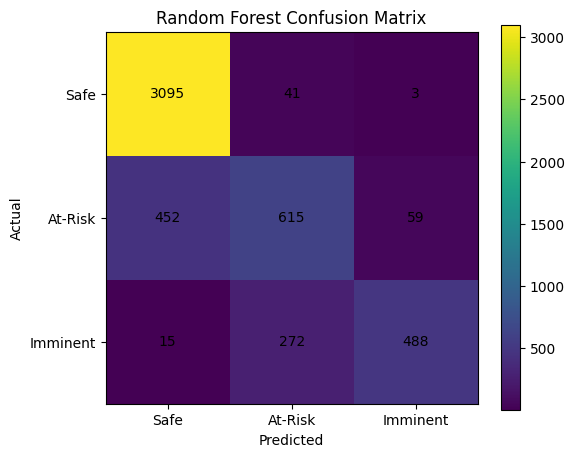

In [33]:
#Random Forest confusion matrix
cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Safe", "At-Risk", "Imminent"]
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.xticks(
    range(3),
    ["Safe", "At-Risk", "Imminent"]
)
plt.yticks(
    range(3),
    ["Safe", "At-Risk", "Imminent"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [34]:
#comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, baseline_pred),
        balanced_accuracy_score(y_test, logistic_pred),
        balanced_accuracy_score(y_test, rf_pred)
    ],
    "Imminent Recall": [
        recall_score(
            y_test, baseline_pred,
            labels=["Imminent"],
            average="macro"
        ),
        recall_score(
            y_test, logistic_pred,
            labels=["Imminent"],
            average="macro"
        ),
        recall_score(
            y_test, rf_pred,
            labels=["Imminent"],
            average="macro"
        )
    ]
})

print(model_comparison)

                 Model  Accuracy  Balanced Accuracy  Imminent Recall
0    Majority Baseline  0.622817           0.333333         0.000000
1  Logistic Regression  0.720833           0.553724         0.432258
2        Random Forest  0.832937           0.720614         0.629677


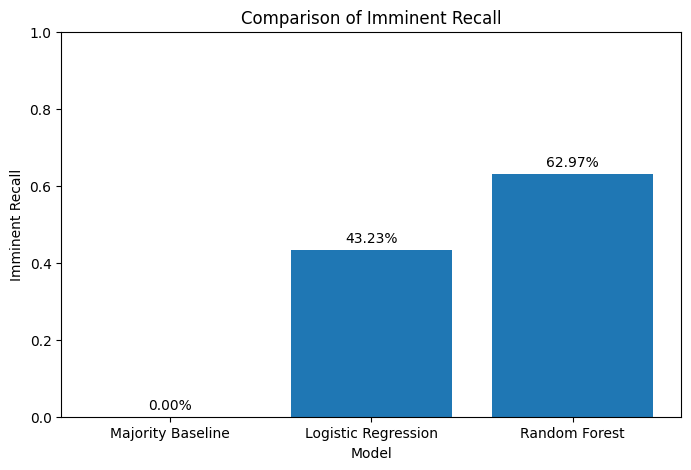

In [35]:
#Model comparison chart
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Imminent Recall"]
)

plt.ylabel("Imminent Recall")
plt.xlabel("Model")
plt.title("Comparison of Imminent Recall")

plt.ylim(0, 1)

for i, value in enumerate(model_comparison["Imminent Recall"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.show()

In [36]:
#Random Forest feature importance
rf_model = random_forest.named_steps["model"]
rf_preprocessor = random_forest.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 15 important features:")
print(importance.head(15))

Top 15 important features:
                              Feature  Importance
1            num__days_of_cover_ratio    0.339599
0                    num__reorder_gap    0.316242
2                   num__day_of_month    0.088908
4                 num__recent_reorder    0.076116
5              num__reliability_clean    0.057518
14          cat__city_clean_Bengaluru    0.010844
9   cat__category_Fruits & Vegetables    0.010759
6                cat__category_Bakery    0.009468
11        cat__category_Personal Care    0.009045
16              cat__city_clean_Delhi    0.008835
18             cat__city_clean_Mumbai    0.008801
17          cat__city_clean_Hyderabad    0.008228
19               cat__city_clean_Pune    0.008144
15            cat__city_clean_Chennai    0.008101
7             cat__category_Beverages    0.007816


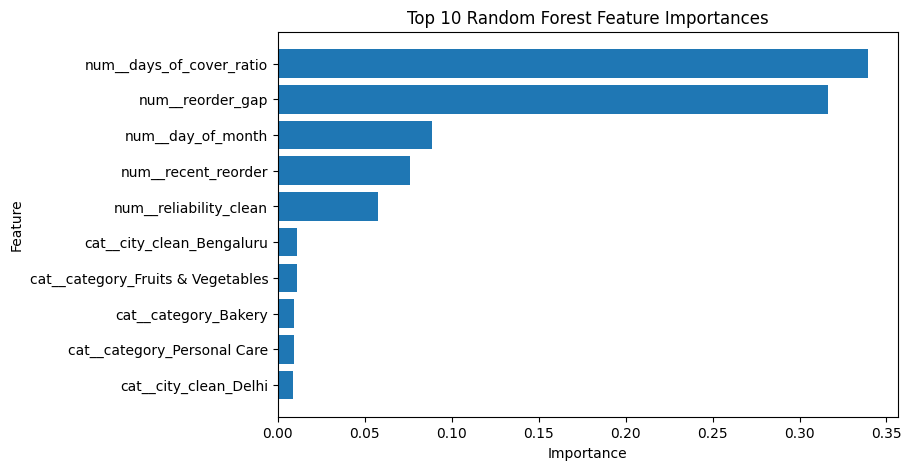

In [37]:
#Top feature importance chart
top_features = importance.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.show()

In [38]:
#Final test-period summary
print("Final Test Period Summary")
print("-------------------------")

print("Test period:",
      test["date"].min().date(),
      "to",
      test["date"].max().date())

print("\nTest rows:", len(test))

print("\nActual stockout risk counts:")
print(y_test.value_counts())

print("\nRandom Forest predictions:")
print(pd.Series(rf_pred).value_counts())

print("\nRandom Forest Imminent recall:",
      f"{recall_score(y_test, rf_pred, labels=['Imminent'], average='macro'):.2%}")

Final Test Period Summary
-------------------------
Test period: 2026-10-24 to 2026-10-30

Test rows: 5040

Actual stockout risk counts:
stockout_risk
Safe        3139
At-Risk     1126
Imminent     775
Name: count, dtype: int64

Random Forest predictions:
Safe        3562
At-Risk      928
Imminent     550
Name: count, dtype: int64

Random Forest Imminent recall: 62.97%


In [39]:
#project conclusion
print("""
PROJECT CONCLUSION
------------------

The QuickCart Warehouse Inventory Stockout Risk model was built using
historical inventory, SKU, store, supplier and event data.

The data was split based on time, with October 1-23 used for training
and October 24-30 used for testing.

Three approaches were compared: Majority Baseline, Logistic Regression
and Random Forest.

The Random Forest model achieved 83.29% accuracy and 72.06% balanced
accuracy on the test data. Its recall for the Imminent class was 62.97%,
compared with 43.23% for Logistic Regression and 0% for the majority
baseline.

The most important features in the Random Forest model were
days_of_cover_ratio and reorder_gap, followed by day_of_month,
recent_reorder and supplier reliability.

Overall, the model was able to identify a substantial portion of the
Imminent stockout cases in the test period and can be used as a
supporting tool for identifying inventory situations that may need
attention.
""")


PROJECT CONCLUSION
------------------

The QuickCart Warehouse Inventory Stockout Risk model was built using
historical inventory, SKU, store, supplier and event data.

The data was split based on time, with October 1-23 used for training
and October 24-30 used for testing.

Three approaches were compared: Majority Baseline, Logistic Regression
and Random Forest.

The Random Forest model achieved 83.29% accuracy and 72.06% balanced
accuracy on the test data. Its recall for the Imminent class was 62.97%,
compared with 43.23% for Logistic Regression and 0% for the majority
baseline.

The most important features in the Random Forest model were
days_of_cover_ratio and reorder_gap, followed by day_of_month,
recent_reorder and supplier reliability.

Overall, the model was able to identify a substantial portion of the
Imminent stockout cases in the test period and can be used as a
supporting tool for identifying inventory situations that may need
attention.

